<a href="https://colab.research.google.com/github/Nadine1818/word2vec-ner-conll2003/blob/main/word2vec_ner_conll2003.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math
import random
import json
from collections import Counter
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from tqdm import tqdm
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import pickle

##Load Dataset


In [2]:
def load_corpus(corpus_name = 'lhoestq/conll2003'):
    #corpus->A collection of text (usually cleaned and ready for training)
    all_sentences = [] # Create an empty list that will store all cleaned sentences
    dataset = load_dataset(corpus_name)

    for split in ['train', 'validation', 'test']:
      #we care about tokens(actual words) only (word2vec learns from texts )
        for example in dataset[split]:
            cleaned_tokens = []
            for token in example['tokens']:
                token = token.lower() #convert token to lower case
                if token.isalpha(): #keeps only tokens contains alphabetic chars
                    cleaned_tokens.append(token)

            if len(cleaned_tokens) > 0:
                all_sentences.append(cleaned_tokens)
    print(f"Total sentences : {len(all_sentences):,}")
    print(f"Total tokens    : {sum(len(s) for s in all_sentences):,}")

    return all_sentences


In [3]:
corpus = load_corpus('lhoestq/conll2003')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dataset_infos.json: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Total sentences : 20,305
Total tokens    : 227,157


##Define Parameters

In [4]:

min_count = 0 #min freq of word(removes rare words, speeds up training, removes noise)
embed_dim = 100 #size of the word vector (accurate enough)
context_size = 5 # no of words to the left and right of the target word
num_negative_samples = 10 # no of fake words sampled per training pair (instead of computing full softmax)
epochs = 10 # no of times the model sees the full dataset
start_alpha = 0.025 # initial learning rate
min_alpha = 0.0001 # Minimum learning rate after decay (prevents overshooting)


##Construct Word-Index Dictionaries
- Convert words into numbers (indices) so the model can understand them
- Two mappings are used: one from word to index(for training) and another from index to word(output)
- Removes rare noise

In [5]:
def build_vocab_mapping(corpus, min_count=0):

    word_counts = Counter()
    for sentence in corpus:
        word_counts.update(sentence) # counts all words in that sentence

    vocab = [] # get all vocab that have >= min count
    for word, count in word_counts.items(): #gives pairs (word = '', its count=#)
        if count >= min_count:
            vocab.append(word)
    word_to_idx = {word: idx for idx, word in enumerate(vocab)} # {'cat': 0, 'dog': 1}
    idx_to_word = {idx: word for idx, word in enumerate(vocab)} # {0: 'cat', 1: 'dog'}
    # enumerate = (index, value)
    return word_to_idx, idx_to_word, word_counts, len(vocab)

In [6]:
word_to_idx, idx_to_word, word_counts, vocab_size = build_vocab_mapping(corpus, min_count)
print(f"Vocabulary size (min_count={min_count}): {vocab_size:,}")

Vocabulary size (min_count=0): 19,828


##Sigmoid Function
- Sigmoid maps any real number to a probability between 0 and 1.
- the score (dot product of two vectors w & c) is passed through sigmoid to get a probability:
   - score > 0  means the model thinks these words are related
   - score < 0  means the model thinks they are unrelated

In [7]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -6, 6)))
    # x is the dot product of word_vector and context_vector
    # np.clip -> make range of x bet (-6,6) to protect the model from overflow
    # np.exp(1000) -> overflow

##Construct Sampling Table
- It builds a probability table to sample words for negative sampling

- Instead of computing probabilities every time, we:

    precompute → store → sample quickly

In [8]:
def create_sampling_table(table_size, power, idx_to_word, word_counts, vocab_size):
  # power -> gives the best balance between frequent and rare words, leading to better embeddings
  # power =0.75 -> it smooths the distribution
  # now rare words > = 2
    sampling_table = np.zeros(int(table_size), dtype=np.uint32)
    # dtype=np.uint32 -> defines the type of numbers stored in the array (unsigned 32-bit integers -> memory efficient)

    # Compute normalization factor (denominator of probability)
    # To make all probabilities sum to 1
    # norm= ∑ ​count(w)^0.75 (for all words)
    norm = sum(word_counts[idx_to_word[i]] ** power for i in range(vocab_size))

    p = 0
    i = 0

    for j in range(vocab_size):
        word  = idx_to_word[j]
        count = word_counts[word]

        # P(w)= count(w)^0.75 / ∑count(w)^0.75​
        # p=cumulative probability up to this word
        p += (count ** power) / norm

        # filling table (with word indeces)
        # frequent words -> occupy more slots
        while i < table_size and (i / table_size) < p:
            sampling_table[i] = j
            i += 1

    return sampling_table

In [9]:
sampling_table = create_sampling_table(1e6, .75, idx_to_word, word_counts, vocab_size)
print(f"Sampling table size: {len(sampling_table):,}")

Sampling table size: 1,000,000


##Weights Initialization

In [10]:
def initialize_weights(vocab_size, embed_dim):
    # target_vectors  -> for center (input) words
    # context_vectors -> for context (output) words
    # create matrix of random numbers (Each row = embedding vector of a word)
    # (-0.5) -> shift values centered around zero, Centering around 0 allows both positive and negative similarities.
    # If vectors were only positive, dot products would always be large.
    # /embed_dim -> makes values small to prevent exploding gradient and unstable training
    target_vectors  = (np.random.rand(vocab_size, embed_dim) - 0.5) / embed_dim
    context_vectors = np.zeros((vocab_size, embed_dim))
    return target_vectors, context_vectors

    # If all vectors started identical (like zeros), the model would suffer from symmetry (Their gradients would always be identical)
    # Random initialization breaks symmetry.
    # why context not random (cause instability and slower convergence)

In [11]:
target_vectors, context_vectors = initialize_weights(vocab_size, embed_dim)

##Extract Negative samples
- It selects fake (negative) words for training
- (target word, random words) → negative pairs
- We randomly pick words → but according to frequency distribution

In [12]:
def get_negative_samples(context_idx, target_idx, num_negative_samples, sampling_table):
    samples = []
    while len(samples) < num_negative_samples:
        # pick a random position in the table
        sample_idx = sampling_table[random.randint(0, len(sampling_table) - 1)]
        # avoid selecting the same word
        if sample_idx != target_idx and sample_idx != context_idx:
            samples.append(sample_idx)
    return samples

##Training Function
- Implements the Skip-Gram model with Negative Sampling
- It maximizes the probability of its true context words while minimizing the probability of randomly sampled negative words
Using:
  - sigmoid function & gradient updates applied to both target and context embeddings

In [13]:
def train(corpus, epochs, start_alpha, min_alpha, num_negative_samples,
         sampling_table, word_to_idx, context_size, embed_dim,
         target_vectors, context_vectors):

    total_steps  = epochs * len(corpus) # total number of updates
    current_step = 0 # track process
    epoch_avg_losses = []

    for epoch in range(1, epochs + 1):
        print(f"\n--- Epoch {epoch}/{epochs} ---")
        epoch_loss_sum = 0
        pairs_in_epoch = 0 # Counter for the denominator

        # tqdm -> progress bar library (shows how much of the loop is done)
        # loop over sentence
        for sentence in tqdm(corpus, desc=f"Epoch {epoch}"):

            # Linear LR decay
            # stabilizes training (decrease learning rate gradually)
            # This helps the model take large steps early (explore) and small
            # steps later (fine-tune without overshooting).
            progress = current_step / total_steps
            alpha    = max(min_alpha, start_alpha * (1.0 - progress))
            current_step += 1

            # convert words to indices ['cat', 'sits'] → [5, 12]
            sentence_indices = [word_to_idx[word] for word in sentence if word in word_to_idx]

            # skip useless sentences
            # need at least 2 words to form a pair
            if len(sentence_indices) < 2:
                continue

            # loop over each target word
            for i, target_idx in enumerate(sentence_indices):

                # Dynamic window size (window size changes randomly)
                # to give closer words more importance and make training more natural
                current_window  = random.randint(1, context_size) #context_size=5

                # define range around target
                start = max(0, i - current_window) #safe left boundry
                end = min(len(sentence_indices), i + current_window + 1) #safe right boundry

                #get context words
                context_indices = [sentence_indices[j] for j in range(start, end) if j != i]

                if not context_indices:
                    continue

                # initialize gradient
                grad_target = np.zeros(embed_dim)

                # Positive pairs (context words)
                for context_idx in context_indices:
                    # measure similarity bet target vector & context vector (cosine similarity)
                    score = target_vectors[target_idx].dot(context_vectors[context_idx])
                    prob = sigmoid(score)
                    # if prob is small → big update
                    # if prob is already high → small update
                    g = alpha * (1 - prob) # 1-prob -> positive pair
                    # positive label = 1

                    # updates vectors
                    # positive pairs -> pull together
                    grad_target += g * context_vectors[context_idx]
                    context_vectors[context_idx] += g * target_vectors[target_idx]

                    # calculating loss per epoch
                    # + 1e-10 -> To avoid numerical errors (log(0)) during training
                    epoch_loss_sum += -np.log(prob + 1e-10)
                    pairs_in_epoch += 1

                # Negative pairs
                negative_samples = get_negative_samples(context_idx, target_idx, num_negative_samples, sampling_table)

                for neg_idx in negative_samples:
                    score = target_vectors[target_idx].dot(context_vectors[neg_idx])
                    prob = sigmoid(score)
                    g = alpha * (0 - prob) # negative label = 0

                    grad_target += g * context_vectors[neg_idx]
                    context_vectors[neg_idx] += g * target_vectors[target_idx]
                    epoch_loss_sum += -np.log(1 - prob + 1e-10)
                    pairs_in_epoch += 1

                target_vectors[target_idx] += grad_target

        #epoch_losses.append(epoch_loss)
        # at the end of each epoch, alongside epoch_loss:
        #normalized_loss = epoch_loss / total_pairs
        avg_loss = epoch_loss_sum / pairs_in_epoch
        epoch_avg_losses.append(avg_loss)
        print(f"Epoch {epoch} Average Loss: {avg_loss:.4f}")

    print("\nTraining complete.")
    return target_vectors, epoch_avg_losses

In [14]:
target_vectors, epoch_losses = train(
    corpus, epochs, start_alpha, min_alpha, num_negative_samples,
    sampling_table, word_to_idx, context_size, embed_dim,
    target_vectors, context_vectors
)


--- Epoch 1/10 ---


Epoch 1: 100%|██████████| 20305/20305 [01:21<00:00, 247.71it/s]


Epoch 1 Average Loss: 0.6537

--- Epoch 2/10 ---


Epoch 2: 100%|██████████| 20305/20305 [01:23<00:00, 243.92it/s]


Epoch 2 Average Loss: 0.5951

--- Epoch 3/10 ---


...

Epoch 8 Average Loss: 0.5160

--- Epoch 9/10 ---


Epoch 9: 100%|██████████| 20305/20305 [01:20<00:00, 252.23it/s]


Epoch 9 Average Loss: 0.5125

--- Epoch 10/10 ---


Epoch 10: 100%|██████████| 20305/20305 [01:19<00:00, 254.07it/s]

Epoch 10 Average Loss: 0.5107

Training complete.


##Plot Losses

In [15]:
def plot_epoch_losses(epoch_losses, save_path="epoch_losses.png"):
    plt.figure(figsize=(15, 5))
    plt.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='skyblue')
    plt.title("Training Loss per Epoch")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(range(1, len(epoch_losses) + 1))
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    print(f"Plot saved to: {save_path}")

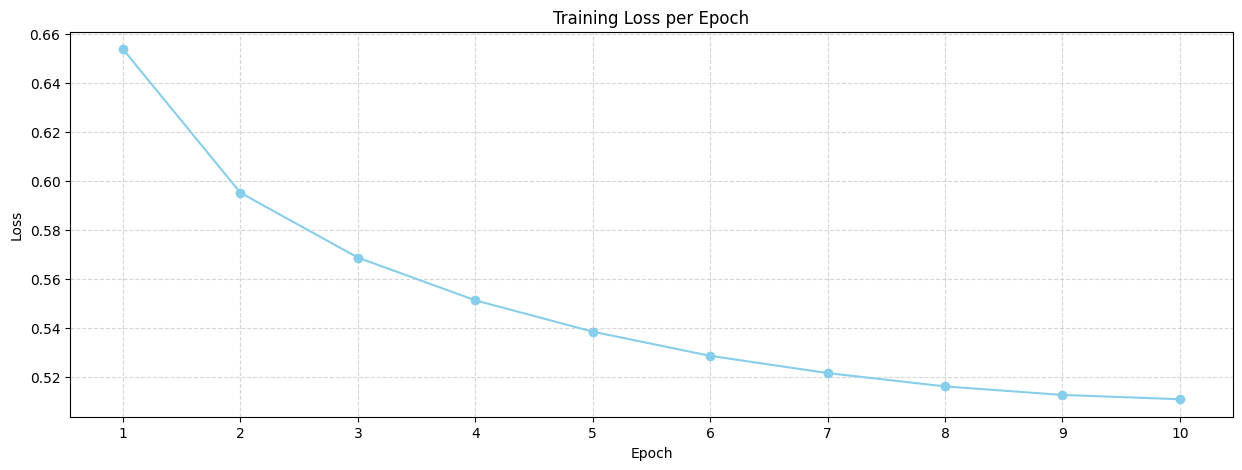

Plot saved to: epoch_losses.png


In [16]:
plot_epoch_losses(epoch_losses)

In [17]:
print("\n" + "="*55)
print("         Training Loss Summary")
print("="*55)
print(f"  {'Epoch':<8} {'Loss':>14} {'Drop from prev':>16}")
print("-"*55)
for i, loss in enumerate(epoch_losses, 1):
    if i == 1:
        drop = "—"
    else:
        diff = epoch_losses[i-2] - loss
        pct  = (diff / epoch_losses[i-2]) * 100
        drop = f"-{diff:,.4f}  ({pct:.2f}%)"
    print(f"  {i:<8} {loss:>14,.4f} {drop:>16}")
print("-"*55)
total_drop = epoch_losses[0] - epoch_losses[-1]
total_pct  = (total_drop / epoch_losses[0]) * 100
print(f"  {'Start':<8} {epoch_losses[0]:>14,.4f}")
print(f"  {'End':<8} {epoch_losses[-1]:>14,.4f}")
print(f"  {'Total drop':<8} {total_drop:>14,.4f}  ({total_pct:.2f}%)")
print("="*55 + "\n")


         Training Loss Summary
  Epoch              Loss   Drop from prev
-------------------------------------------------------
  1                0.6537                —
  2                0.5951 -0.0586  (8.97%)
  3                0.5686 -0.0265  (4.45%)
  4                0.5511 -0.0175  (3.07%)
  5                0.5383 -0.0128  (2.32%)
  6                0.5285 -0.0099  (1.83%)
  7                0.5214 -0.0070  (1.33%)
  8                0.5160 -0.0055  (1.05%)
  9                0.5125 -0.0035  (0.67%)
  10               0.5107 -0.0018  (0.34%)
-------------------------------------------------------
  Start            0.6537
  End              0.5107
  Total drop         0.1430  (21.87%)



##Save Embeddings And Word to Index Mapping


In [18]:
def save_embeddings(target_vectors, word_to_idx, idx_to_word,
                    vectors_path="word_embeddings.npy",
                    vocab_path="vocab.pkl"):
    # target_vectors -> the learned embedding matrix, shape: (vocab_size, embed_dim)
    # each row is the vector representation of one word
    # vectors_path -> saves embedding matrix
    # vocab_path -> saves vocab dictionaries (word↔index dicts)

    # Save the embedding matrix as a .npy file
    np.save(vectors_path, target_vectors)

    # Save both vocab mappings together in one pickle file
    vocab_data = {
        "word_to_idx": word_to_idx, # during training word -> index
        "idx_to_word": idx_to_word # converts model output index to word
    }

    #saves raw bytes (binary mode)
    with open(vocab_path, "wb") as f:
        pickle.dump(vocab_data, f)

    print(f"Embeddings saved to   : {vectors_path}  → shape {target_vectors.shape}")
    print(f"Vocabulary saved to   : {vocab_path}    → {len(word_to_idx):,} words")

save_embeddings(target_vectors, word_to_idx, idx_to_word)

Embeddings saved to   : word_embeddings.npy  → shape (19828, 100)
Vocabulary saved to   : vocab.pkl    → 19,828 words


## Word Analogy Function
  - The analogy task is: "A is to B as A* is to ?"
    - "king is to queen, as man is to ?" → answer: woman
    - queen - king = woman - man  "direction = female version of"
    - therefore woman = queen - king + man
    - queen - king = the "female version of" arrow (king -> queen)
    - so we compute the score between "queen - king + man" vector and every single word in the vocab

In [19]:
def load_embeddings(vectors_path="word_embeddings.npy",
                    vocab_path="vocab.pkl"):
    # Load saved embeddings and vocab back into memory
    target_vectors = np.load(vectors_path)
    with open(vocab_path, "rb") as f:
        vocab_data = pickle.load(f)
    return target_vectors, vocab_data["word_to_idx"], vocab_data["idx_to_word"]


def get_vector(word, word_to_idx, target_vectors):
    # Return the embedding vector for a word
    word = word.lower()
    if word not in word_to_idx:
        raise ValueError(f"Word '{word}' not found in vocabulary.")
    # return the row of target vector
    return target_vectors[word_to_idx[word]]


In [20]:
def word_analogy(word_a, word_b, word_astar,
                 target_vectors, word_to_idx, idx_to_word,
                 topn=5):
    # B* ≈ vec(B) - vec(A) + vec(A*)
    # word_a —> the base word (king)
    # word_b -> the transformed word (queen)
    # word_astar -> the query word (man)
    # target_vectors-> the full embedding matrix (vocab_size x embed_dim)
    # topn -> how many best candidates to return (default 5)

    # normalize to lowercase
    word_a     = word_a.lower()
    word_b     = word_b.lower()
    word_astar = word_astar.lower()

    # Check all words exist in vocab
    for w in [word_a, word_b, word_astar]:
        if w not in word_to_idx:
            print(f"  Word '{w}' not in vocabulary — analogy skipped.")
            # return an empty list instead of crashing with a KeyError
            return []

    # retrieve the embedding vector of each
    vec_a     = get_vector(word_a,     word_to_idx, target_vectors)
    vec_b     = get_vector(word_b,     word_to_idx, target_vectors)
    vec_astar = get_vector(word_astar, word_to_idx, target_vectors)

    # Compute the analogy vector: B - A + A*
    analogy_vec = vec_b - vec_a + vec_astar  # shape: (embed_dim,)

    # Normalize the analogy vector for cosine similarity
    # np.linalg.norm() -> computes the magnitude (length) of the vector
    # magnitude = sqrt(x1² + x2² + ... + xn²) -> for vector length = 1
    analogy_norm = analogy_vec / (np.linalg.norm(analogy_vec) + 1e-10)

    # Normalize ALL embedding vectors (for efficient cosine similarity)
    norms_magnitude = np.linalg.norm(target_vectors, axis=1, keepdims=True) + 1e-10
    normed_vectors = target_vectors / norms_magnitude  # shape: (vocab_size, embed_dim)

    # Cosine similarity between analogy vector and every word vector
    similarities = normed_vectors.dot(analogy_norm)  # shape: (vocab_size,)

    # Exclude the three input words from results
    input_indices = {word_to_idx[w] for w in [word_a, word_b, word_astar]}
    for idx in input_indices:
        similarities[idx] = -1  # push them to the bottom

    # Get top-N results
    # np.argsort(similarities) → returns indices that sorts the array in ascending order (smallest first)
    # then reverses the order and keeps topn only
    top_indices = np.argsort(similarities)[::-1][:topn]
    # builds a list of (word, score) tuples
    results = [(idx_to_word[idx], float(similarities[idx])) for idx in top_indices]

    return results


In [21]:
def run_analogy_demo(target_vectors, word_to_idx, idx_to_word):

    test_cases = [
        ("france",  "french",  "germany"),    # country → language/nationality
        ("he",      "his",     "she"),        # pronoun → possessive
        ("arsenal", "london", "manchester"),   # club → city
        ("won", "win", "lost")                # past → present tense
    ]

    print("Word Analogy Results: ")
    print("Format:  A  :  B  ::  A*  :  ? ")

    for word_a, word_b, word_astar in test_cases:
        print(f"\n  {word_a}  :  {word_b}  ::  {word_astar}  :  ?")
        print(f"  {'-'*50}")

        results = word_analogy(word_a, word_b, word_astar,
                               target_vectors, word_to_idx, idx_to_word,
                               topn=5)
        if results:
            for rank, (word, score) in enumerate(results, 1):
                print(f"    {rank}. {word:<20}  cosine similarity: {score:.4f}")
        print()

    print("="*65)

run_analogy_demo(target_vectors, word_to_idx, idx_to_word)

Word Analogy Results: 
Format:  A  :  B  ::  A*  :  ? 

  france  :  french  ::  germany  :  ?
  --------------------------------------------------
    1. premier               cosine similarity: 0.8623
    2. australian            cosine similarity: 0.8570
    3. scottish              cosine similarity: 0.8473
    4. spanish               cosine similarity: 0.8428
    5. summary               cosine similarity: 0.8328


  he  :  his  ::  she  :  ?
  --------------------------------------------------
    1. her                   cosine similarity: 0.7521
    2. him                   cosine similarity: 0.6198
    3. teresa                cosine similarity: 0.5969
    4. place                 cosine similarity: 0.5746
    5. their                 cosine similarity: 0.5719


  arsenal  :  london  ::  manchester  :  ?
  --------------------------------------------------
    1. johannesburg          cosine similarity: 0.8915
    2. frankfurt             cosine similarity: 0.8851
    3. kara

## Part 2: NER Using Neural Network

In [22]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from collections import Counter

In [23]:
target_vectors, word_to_idx, idx_to_word = load_embeddings()
# Load the saved word embedding matrix and vocabulary mappings from disk.
# target_vectors shape: (vocab_size, embed_dim)
# word_to_idx maps each word string to its numeric index.
# idx_to_word maps numeric indices back to word strings.

embed_dim = target_vectors.shape[1]   # 100
# The embedding dimension is the number of features per word vector.

# OOV vector = mean of all embeddings (keeps vectors in same distribution)
oov_vector = target_vectors.mean(axis=0)
# Use the average embedding for any out-of-vocabulary word.
# This keeps unseen words in the same vector distribution as known words.


In [24]:
# Load the CONLL-2003 NER dataset; each split contains token sequences and NER tags.
dataset = load_dataset('lhoestq/conll2003')
# After this, dataset['train'], dataset['validation'], dataset['test'] are available.


In [25]:
tags = ['O', 'B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']
# O = Outside (not an entity)
# B- = Beginning of an entity span
# I- = Inside of an entity span

# Map each tag string to a numeric index for model training.
tag_to_idx = {tag: i for i, tag in enumerate(tags)}
# Map numeric model outputs back to tag strings.
idx_to_tag = {i: tag for i, tag in enumerate(tags)}
num_classes = len(tags)
# Total number of label classes the model predicts.

print(f"Total labels to predict: {num_classes}")


Total labels to predict: 9


In [26]:
WINDOW = 2  # Number of words to include to the left and right of each token
# The model input for a token is the concatenation of its own embedding plus
# the embeddings of WINDOW tokens on both sides.


In [27]:
def get_word_vector(token):
    token = token.lower()
    # Normalize token case to match the vocabulary keys.
    if token in word_to_idx:
        return target_vectors[word_to_idx[token]]
        # Return the learned embedding for a known token.
    return oov_vector  # mean vector for OOV
    # For unknown tokens, return the average vector of all known embeddings.


In [28]:
def sentence_to_features(tokens, window=WINDOW):
    """
    Returns array of shape (n_tokens, (2*window+1)*embed_dim).
    Positions outside sentence boundaries are padded with oov_vector.
    """
    vecs = [get_word_vector(t) for t in tokens]
    # Convert each token in the sentence into its corresponding vector.
    n = len(tokens)
    features = []

    for i in range(n):
        ctx = []
        for offset in range(-window, window + 1):
            j = i + offset
            # If the context position is inside the sentence, use that token's vector.
            # Otherwise, use the out-of-vocabulary average vector as padding.
            ctx.append(vecs[j] if 0 <= j < n else oov_vector)
        # Concatenate the center token's vector and its context vectors.
        features.append(np.concatenate(ctx))

    # Return a float32 array shaped (n_tokens, context_width * embed_dim).
    return np.array(features, dtype=np.float32)


In [29]:
def build_split(split_name):
    # Build feature matrices X and label arrays y for one dataset split.
    X_all, y_all = [], []

    for example in tqdm(dataset[split_name], desc=f"Features [{split_name}]"):
        # Convert the token sequence into feature vectors for each token.
        feats = sentence_to_features(example["tokens"])
        X_all.append(feats)
        # Extend the label list by appending all token tags for this example.
        y_all.extend(example["ner_tags"])

    # Stack all sentence-level arrays into a single matrix.
    X = np.vstack(X_all)
    # Convert labels into a numpy array of integers.
    y = np.array(y_all, dtype=np.int64)

    print(f"  {split_name:10s}: {X.shape[0]:,} tokens | input_dim={X.shape[1]}")
    return X, y


In [30]:
print("\nExtracting features …")
# Precompute features for every token in each split of the dataset.
X_train, y_train = build_split("train")
X_val,   y_val   = build_split("validation")
X_test,  y_test  = build_split("test")



Extracting features …


Features [train]: 100%|██████████| 14041/14041 [00:04<00:00, 3267.15it/s]


  train     : 203,621 tokens | input_dim=500


Features [validation]: 100%|██████████| 3250/3250 [00:00<00:00, 4282.36it/s]


  validation: 51,362 tokens | input_dim=500


Features [test]: 100%|██████████| 3453/3453 [00:00<00:00, 4904.89it/s]


  test      : 46,435 tokens | input_dim=500


In [31]:
input_dim = X_train.shape[1]  # 500
# Determine the input dimensionality of the neural network.
label_counts = Counter(y_train.tolist())
# Count how many times each tag appears in the training set.
total_tokens = sum(label_counts.values())
class_weights = np.array(
    [np.sqrt(total_tokens / (num_classes * label_counts.get(i, 1)))
     for i in range(num_classes)],
    dtype=np.float32
)
# Use class weights to reduce the impact of class imbalance.
# The square root stabilizes the scaling.
class_weights_tensor = torch.tensor(class_weights)
# Convert class weights into a PyTorch tensor for the loss function.


In [32]:
class NERDataset(Dataset):
    def __init__(self, X, y):
        # Convert numpy arrays to PyTorch tensors for fast batch loading.
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        # Return the total number of token examples in the dataset.
        return len(self.y)

    def __getitem__(self, idx):
        # Return the features and label for one token at index idx.
        return self.X[idx], self.y[idx]


In [33]:
BATCH_SIZE = 256

In [34]:
train_loader = DataLoader(
    NERDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)
# Shuffle training data to improve generalization by varying batch contents each epoch.

val_loader = DataLoader(
    NERDataset(X_val, y_val),
    batch_size=BATCH_SIZE
)
# Validation data is not shuffled to keep evaluation consistent.

test_loader = DataLoader(
    NERDataset(X_test, y_test),
    batch_size=BATCH_SIZE
)
# Test data loader for final evaluation.


In [35]:
class NERClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropouts):
        super().__init__()
        # The network is a stack of fully connected layers.
        layers = [nn.BatchNorm1d(input_dim)]
        in_d = input_dim

        for h, drop in zip(hidden_dims, dropouts):
            layers += [
                nn.Linear(in_d, h),    # Dense layer from in_d -> h units.
                nn.LayerNorm(h),       # Normalize the hidden layer outputs.
                nn.ReLU(),             # Add non-linearity for expressive power.
                nn.Dropout(drop),      # Dropout helps prevent overfitting.
            ]
            in_d = h

        # Final linear layer outputs one score per tag class.
        layers.append(nn.Linear(in_d, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        # x shape: (batch_size, input_dim)
        # returns logits shape: (batch_size, num_classes)
        return self.net(x)


In [36]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Use GPU if available; otherwise fall back to CPU.
print(f"\nDevice: {device}")



Device: cpu


In [37]:
model = NERClassifier(
    input_dim   = input_dim,
    hidden_dims = [512,256, 128],
    num_classes = num_classes,
    dropouts    = [0.4,0.3, 0.2]
).to(device)
# Move the model to the selected device (GPU or CPU).

# The model uses three hidden layers with decreasing width.
# This architecture encourages hierarchical feature extraction.


In [38]:

print(model)
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

NERClassifier(
  (net): Sequential(
    (0): BatchNorm1d(500, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Linear(in_features=500, out_features=512, bias=True)
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (3): ReLU()
    (4): Dropout(p=0.4, inplace=False)
    (5): Linear(in_features=512, out_features=256, bias=True)
    (6): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=128, bias=True)
    (10): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=128, out_features=9, bias=True)
  )
)
Trainable params: 424,689


In [39]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
# CrossEntropyLoss expects raw logits and integer class labels.
# Weighted loss compensates for class imbalance.

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# AdamW is an optimizer with decoupled weight decay for better regularization.

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20, eta_min=1e-5)
# CosineAnnealingLR lowers the learning rate smoothly from initial to eta_min.


In [40]:
EPOCHS   = 20
# Number of full passes over the training data.
PATIENCE = 4
# Number of epochs without improvement before early stopping.

best_val_f1  = 0.0
# Track the best validation score seen so far.
patience_cnt = 0
# Count epochs since last improvement.
best_weights = None
# Store a copy of the best model weights.

train_losses, val_losses = [], []
train_f1s,    val_f1s    = [], []
# Store loss and F1 metrics for plotting later.


In [41]:
def evaluate(loader):
    model.eval()
    # Turn off gradient tracking for evaluation.
    total_loss, preds_all, labels_all = 0.0, [], []

    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            # Forward pass to get logits.
            logits = model(xb)
            loss   = criterion(logits, yb)
            # Accumulate the loss weighted by batch size.
            total_loss += loss.item() * len(yb)
            preds_all.extend(logits.argmax(1).cpu().numpy())
            labels_all.extend(yb.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    # Compute macro F1 across all classes equally.
    macro_f1 = f1_score(labels_all, preds_all, average="macro", zero_division=0)
    return avg_loss, macro_f1, preds_all, labels_all


In [42]:
best_val_acc = 0.0
# Track the highest validation accuracy seen so far.
patience_cnt = 0
best_weights = None
train_losses, val_losses = [], []
train_accs, val_accs     = [], []

print("\n" + "="*65)
print("          TRAINING FEED-FORWARD NER MODEL")
print("="*65)

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss, preds_all, labels_all = 0.0, [], []

    for xb, yb in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS}", leave=False):
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        # Zero the optimizer gradients from the previous batch.

        logits = model(xb)
        # Forward pass: compute raw scores for each class.

        loss = criterion(logits, yb)
        # Compute batch loss using weighted cross-entropy.

        loss.backward()
        # Backpropagate gradients through the network.

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        # Clip gradients to prevent exploding gradients.

        optimizer.step()
        # Update model weights using the optimizer.

        epoch_loss += loss.item() * len(yb)
        preds_all.extend(logits.argmax(1).cpu().numpy())
        labels_all.extend(yb.cpu().numpy())
        # Collect predictions and labels for epoch metrics.

    scheduler.step()
    # Update the learning rate after each epoch.

    tr_loss = epoch_loss / len(train_loader.dataset)
    # Average training loss over all training tokens.

    tr_acc = accuracy_score(labels_all, preds_all)
    # Calculate training accuracy for this epoch.

    vl_loss, _, vl_preds, vl_labels = evaluate(val_loader)
    # Evaluate on validation split.

    vl_acc = accuracy_score(vl_labels, vl_preds)
    # Calculate validation accuracy.

    train_losses.append(tr_loss);  val_losses.append(vl_loss)
    train_accs.append(tr_acc);     val_accs.append(vl_acc)

    print(f"Epoch {epoch:02d} | "
          f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f} | "
          f"LR: {scheduler.get_last_lr()[0]:.2e}")

    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        patience_cnt = 0
        # Save a deep copy of the current best weights.

        print(f"  New best val Accuracy: {best_val_acc:.4f} — checkpoint saved")
    else:
        patience_cnt += 1
        # Increase patience counter when no improvement.

        if patience_cnt >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

model.load_state_dict(best_weights)
# Restore the best model weights after training.
print(f"\nBest validation Accuracy: {best_val_acc:.4f}")



          TRAINING FEED-FORWARD NER MODEL


Epoch 01 | Train Loss: 0.9738  Acc: 0.8361 | Val Loss: 0.7800  Acc: 0.8846 | LR: 9.94e-04
  New best val Accuracy: 0.8846 — checkpoint saved


Epoch 02 | Train Loss: 0.7915  Acc: 0.8644 | Val Loss: 0.6947  Acc: 0.8912 | LR: 9.76e-04
  New best val Accuracy: 0.8912 — checkpoint saved


Epoch 03 | Train Loss: 0.7228  Acc: 0.8761 | Val Loss: 0.6603  Acc: 0.8902 | LR: 9.46e-04


Epoch 04 | Train Loss: 0.6803  Acc: 0.8825 | Val Loss: 0.6442  Acc: 0.8932 | LR: 9.05e-04
  New best val Accuracy: 0.8932 — checkpoint saved


...

Epoch 14 | Train Loss: 0.4731  Acc: 0.9086 | Val Loss: 0.5373  Acc: 0.9210 | LR: 2.14e-04
  New best val Accuracy: 0.9210 — checkpoint saved


Epoch 15 | Train Loss: 0.4593  Acc: 0.9104 | Val Loss: 0.5388  Acc: 0.9174 | LR: 1.55e-04


Epoch 16 | Train Loss: 0.4481  Acc: 0.9118 | Val Loss: 0.5386  Acc: 0.9181 | LR: 1.05e-04


Epoch 17 | Train Loss: 0.4429  Acc: 0.9119 | Val Loss: 0.5436  Acc: 0.9201 | LR: 6.40e-05


Epoch 18 | Train Loss: 0.4370  Acc: 0.9126 | Val Loss: 0.5339  Acc: 0.9177 | LR: 3.42e-05

Early stopping triggered at epoch 18.

Best validation Accuracy: 0.9210


In [43]:
def get_all_predictions(model, loader, device):
    """Run inference on a DataLoader and return true labels and predicted labels."""
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            logits  = model(X_batch)
            # Choose the class with the highest logit score.
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())

    return np.array(all_labels), np.array(all_preds)


In [44]:
y_true, y_pred = get_all_predictions(model, test_loader, device)

# Compute final evaluation metrics on the test split.
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
rec  = recall_score(y_true, y_pred,    average='macro', zero_division=0)
f1   = f1_score(y_true, y_pred,        average='macro', zero_division=0)

ffnn_results = {
    'accuracy':  acc,
    'precision': prec,
    'recall':    rec,
    'f1':        f1,
    'y_true':    y_true,
    'y_pred':    y_pred,
}


In [45]:
print("\n" + "="*65)
print("       FEED-FORWARD NN — FINAL TEST SET RESULTS")
print("="*65)
print(f"  Accuracy  : {acc :.4f}  ({acc*100:.2f}%)")
print(f"  Precision : {prec:.4f}")
print(f"  Recall    : {rec :.4f}")
print(f"  Macro-F1  : {f1  :.4f}")
print("="*65)

print("\nPer-class Report:")
print(classification_report(y_true, y_pred,
                             target_names=tag_to_idx, zero_division=0))


       FEED-FORWARD NN — FINAL TEST SET RESULTS
  Accuracy  : 0.9043  (90.43%)
  Precision : 0.6168
  Recall    : 0.7131
  Macro-F1  : 0.6564

Per-class Report:
              precision    recall  f1-score   support

           O       0.97      0.95      0.96     38323
       B-PER       0.76      0.78      0.77      1617
       I-PER       0.81      0.84      0.83      1156
       B-ORG       0.55      0.58      0.57      1661
       I-ORG       0.50      0.59      0.54       835
       B-LOC       0.67      0.77      0.72      1668
       I-LOC       0.45      0.66      0.53       257
      B-MISC       0.48      0.60      0.53       702
      I-MISC       0.36      0.65      0.46       216

    accuracy                           0.90     46435
   macro avg       0.62      0.71      0.66     46435
weighted avg       0.91      0.90      0.91     46435



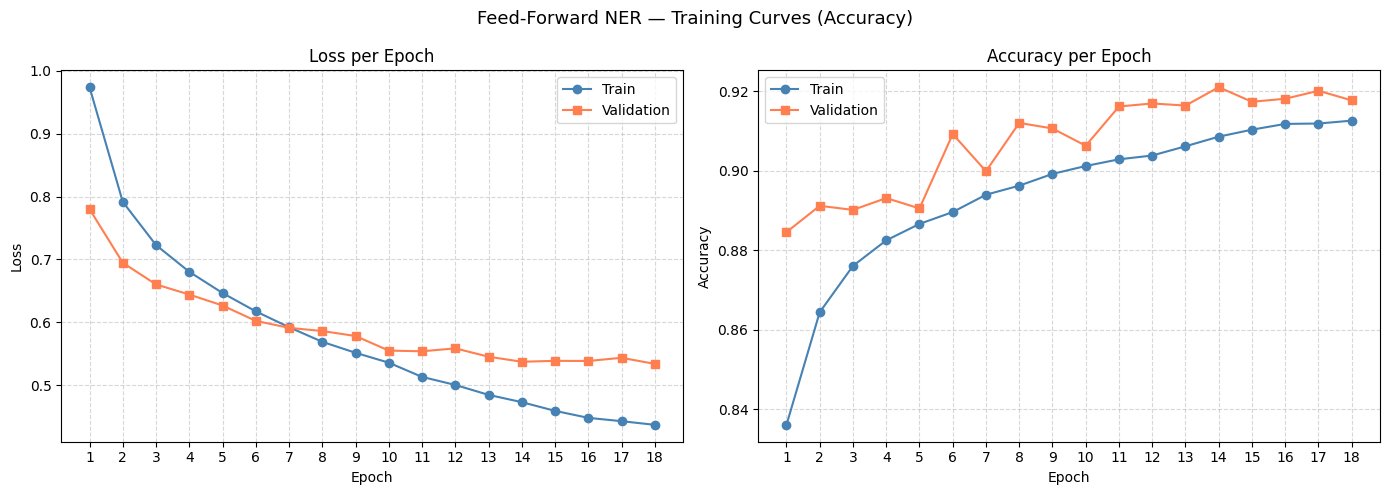

In [46]:
epochs_ran = len(train_losses)

fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

# -------- Loss Plot --------
axes[0].plot(range(1, epochs_ran+1), train_losses,
             marker='o', color='steelblue', label='Train')

axes[0].plot(range(1, epochs_ran+1), val_losses,
             marker='s', color='coral', label='Validation')

axes[0].set_title("Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].set_xticks(range(1, epochs_ran+1))


# -------- Accuracy Plot (UPDATED) --------
axes[1].plot(range(1, epochs_ran+1), train_accs,
             marker='o', color='steelblue', label='Train')

axes[1].plot(range(1, epochs_ran+1), val_accs,
             marker='s', color='coral', label='Validation')

axes[1].set_title("Accuracy per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].set_xticks(range(1, epochs_ran+1))


plt.suptitle("Feed-Forward NER — Training Curves (Accuracy)", fontsize=13)
plt.tight_layout()
plt.show()



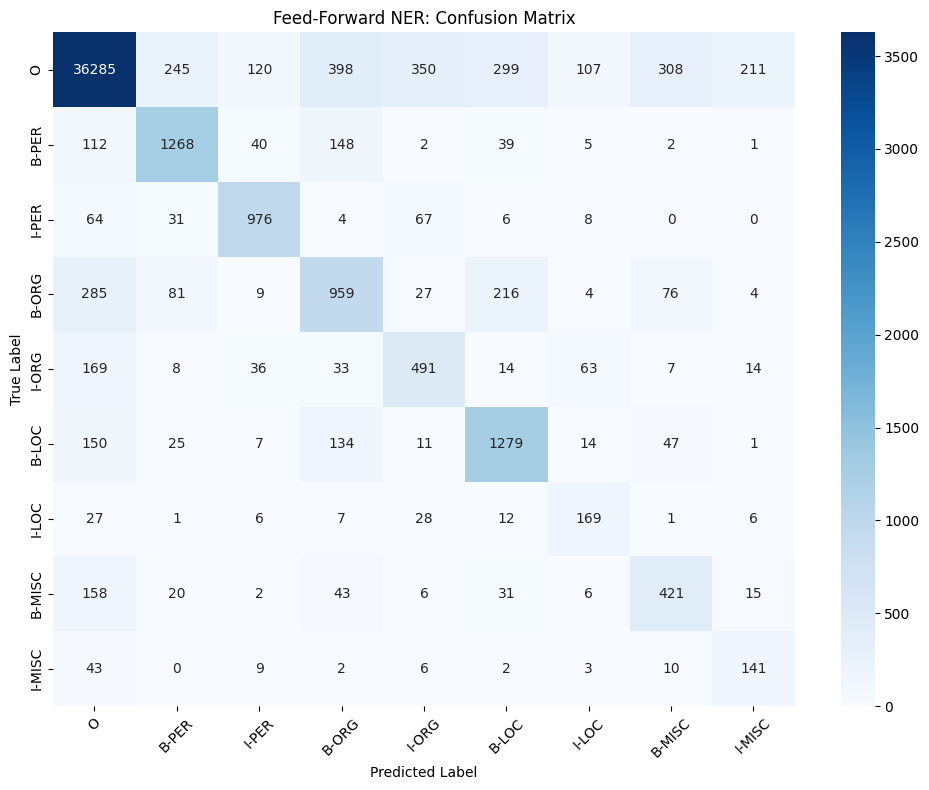

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
# Using a log scale for colors is helpful in NER because the 'O' tag
# numbers are massive compared to everything else.
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=tags, yticklabels=tags,
            vmax=cm.diagonal().max() // 10) # Caps color scale to make rare tags visible

plt.title('Feed-Forward NER: Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45)
plt.tight_layout()


# Part 2: NER Using Hidden Markov Model (HMM)

In [48]:
raw_dataset=dataset

In [49]:
sentences = [] # List to store tokenized sentences
tags = []      # List to store corresponding NER tags for each token

# Iterate through the 'train' split of the raw_dataset
for example in raw_dataset["train"]:
    sentences.append(example["tokens"]) # Append the list of tokens (words) for the current sentence
    tags.append(example["ner_tags"])    # Append the list of numerical NER tags for the current sentence

In [50]:
# Convert numerical tag IDs to human-readable tag names

# idx_to_tag maps numerical indices (0, 1, ...) to their corresponding tag strings ('O', 'B-PER', etc.)
label_list = list(idx_to_tag.values())

# Convert the list of lists of numerical tags into a list of lists of tag strings
tags = [[label_list[tag] for tag in sent] for sent in tags]

In [51]:
# build word counts
word_counts = Counter()

for sent in sentences:
    for w in sent:
        word_counts[w] += 1


In [52]:
MIN_FREQ = 2

sentences = [
    [
        w if word_counts[w] >= MIN_FREQ else "<UNK>"
        for w in sent
    ]
    for sent in sentences
]

## Compute Probabilities
### 1. Transition Probabilities
P(Si | Si-1)

In [53]:
from collections import defaultdict

transition_counts = defaultdict(lambda: defaultdict(int)) # Stores counts of (previous_tag, current_tag) pairs

# Iterate through each sequence of tags (sentence's tags)
for tag_seq in tags:
    # Iterate from the second tag to the end to get (prev, curr) pairs
    for i in range(1, len(tag_seq)):
        prev_tag = tag_seq[i-1] # The tag at the previous position
        curr_tag = tag_seq[i]   # The tag at the current position
        # Increment the count for this specific transition (prev_tag -> curr_tag)
        transition_counts[prev_tag][curr_tag] += 1

# Normalize the counts to get probabilities:
# P(curr_tag | prev_tag) = count(prev_tag, curr_tag) + 1 / count(prev_tag) +v
transition_probs = {}
num_tags = len(label_list)

for prev_tag in transition_counts:
    total = sum(transition_counts[prev_tag].values())

    transition_probs[prev_tag] = {
        curr_tag: (transition_counts[prev_tag].get(curr_tag, 0) + 1) / (total + num_tags)
        for curr_tag in label_list
    }

import pandas as pd

df = pd.DataFrame(transition_probs).fillna(0)

print(df)

           B-ORG         O    B-MISC     B-PER     B-LOC     I-ORG     I-PER  \
O       0.595150  0.888797  0.709319  0.343521  0.844438  0.659434  0.942202   
B-PER   0.000642  0.033175  0.017236  0.000153  0.000284  0.001099  0.000229   
I-PER   0.000161  0.000006  0.000292  0.654798  0.000142  0.000275  0.056193   
B-ORG   0.003051  0.024273  0.009641  0.000153  0.001563  0.001923  0.000229   
I-ORG   0.399229  0.000006  0.000292  0.000153  0.000142  0.335073  0.000229   
B-LOC   0.000321  0.035414  0.002629  0.000611  0.001279  0.000549  0.000229   
I-LOC   0.000161  0.000006  0.000292  0.000153  0.148032  0.000275  0.000229   
B-MISC  0.001124  0.018315  0.009349  0.000306  0.003978  0.001099  0.000229   
I-MISC  0.000161  0.000006  0.250949  0.000153  0.000142  0.000275  0.000229   

          I-MISC     I-LOC  
O       0.693410  0.882616  
B-PER   0.003820  0.000896  
I-PER   0.000955  0.000896  
B-ORG   0.007641  0.001792  
I-ORG   0.000955  0.000896  
B-LOC   0.002865  0.00358

### 2. Emission Probabilities
P(word | Si)

In [54]:
emission_counts = defaultdict(lambda: defaultdict(int)) # Stores counts of (tag, word) pairs
tag_counts = defaultdict(int)                           # Stores counts of each individual tag

vocab = set()

for sent in sentences:
    vocab.update(sent)

vocab_size = len(vocab) #get vocab size

# Iterate through sentences and their corresponding tag sequences
for sent, tag_seq in zip(sentences, tags):
    # Iterate through each word and its tag in the current sentence
    for word, tag in zip(sent, tag_seq):
        emission_counts[tag][word] += 1 # Increment count for (tag, word) occurrence
        tag_counts[tag] += 1            # Increment count for the tag itself

# Normalize the counts to get probabilities:
# P(word | tag) = count(tag, word) + 1 / count(tag) + v
emission_probs = {}

for tag in emission_counts:
    emission_probs[tag] = {
        word: (emission_counts[tag].get(word, 0) + 1) / (tag_counts[tag] + vocab_size)
        for word in vocab
    }


df_emission = pd.DataFrame(emission_probs).fillna(0)

print(df_emission)

                  B-ORG         O    B-MISC     B-PER     I-PER     B-LOC  \
Conroy         0.000055  0.000006  0.000065  0.000161  0.000121  0.000052   
patrol         0.000055  0.000017  0.000065  0.000054  0.000061  0.000052   
Leopold        0.000055  0.000006  0.000065  0.000054  0.000182  0.000052   
Monetary       0.000055  0.000006  0.000065  0.000054  0.000061  0.000052   
Duisburg       0.000219  0.000006  0.000065  0.000054  0.000061  0.000052   
...                 ...       ...       ...       ...       ...       ...   
Grobbelaar     0.000055  0.000006  0.000065  0.000269  0.000121  0.000052   
4.32           0.000055  0.000017  0.000065  0.000054  0.000061  0.000052   
books          0.000055  0.000094  0.000065  0.000054  0.000061  0.000052   
feels          0.000055  0.000022  0.000065  0.000054  0.000061  0.000052   
Wolverhampton  0.000382  0.000006  0.000065  0.000054  0.000061  0.000052   

                  I-ORG    I-MISC     I-LOC  
Conroy         0.000064  0.00

### 3. Initial Probabilities

P(tag at position 0)

In [55]:
initial_counts = defaultdict(int) # Stores counts of tags appearing at the beginning of sentences

# Iterate through each tag sequence (sentence's tags)
for tag_seq in tags:
    initial_counts[tag_seq[0]] += 1 # Increment count for the first tag in the sequence

total_sentences = len(tags) # Total number of sentences in the training data
num_tags = len(label_list)

# Normalize the counts to get probabilities:
# P(tag at position 0) = count(tag at position 0) + 1 / total_sentences + v
initial_probs = {
    tag: (initial_counts.get(tag, 0) + 1) / (total_sentences + num_tags)
    for tag in label_list
}
df_initial = pd.DataFrame.from_dict(initial_probs, orient="index", columns=["P(tag_start)"])

print(df_initial)

        P(tag_start)
O           0.580427
B-PER       0.096085
I-PER       0.000071
B-ORG       0.174804
I-ORG       0.000071
B-LOC       0.112598
I-LOC       0.000071
B-MISC      0.035801
I-MISC      0.000071


## Viterbi Algorithm
V_t ​(test_tag)= MAXi ​[ V_t−1​(i_tag) * P( test_tag ∣ i_tag )] * P(word_t ​∣ test_tag )]

In [56]:
import numpy as np

def viterbi(sentence, tags, initial_probs, transition_probs, emission_probs):
    # V stores the maximum log probability of a tag sequence ending at a given time step
    V = [{}]
    # path stores the backpointers to reconstruct the best path
    path = {}

    # Initialize for the first word (t=0)
    for tag in tags:
        # Get emission probability P(word_0 | tag), default to a small value (1e-6) to avoid log(0)
        emission = emission_probs[tag].get(sentence[0], 1e-6)
        # Calculate log probability: log(P(tag_0)) + log(P(word_0 | tag_0))
        V[0][tag] = np.log(initial_probs.get(tag, 1e-6)) + np.log(emission)
        path[tag] = [tag] # The path for this tag starts with itself

    # Recursion for t > 0
    for t in range(1, len(sentence)):
        V.append({}) # Add a dictionary for the current time step
        new_path = {} # New path dictionary for the current time step

        for curr_tag in tags:
            # Get emission probability P(word_t | curr_tag)
            emission = emission_probs[curr_tag].get(sentence[t], 1e-6)

            # Find the previous tag (prev_tag) that maximizes the probability
            # P(curr_tag, prev_tag, ..., word_0) = V[t-1][prev_tag] + log(P(curr_tag | prev_tag)) + log(P(word_t | curr_tag))
            prob, best_prev = max(
                (
                    V[t-1][prev_tag] # Max log prob up to prev_tag at t-1
                    + np.log(transition_probs.get(prev_tag, {}).get(curr_tag, 1e-6)) # log(P(curr_tag | prev_tag))
                    + np.log(emission), # log(P(word_t | curr_tag))
                    prev_tag # The previous tag that yielded this max probability
                )
                for prev_tag in tags # Iterate over all possible previous tags
            )

            V[t][curr_tag] = prob # Store the maximum log probability for curr_tag at time t
            new_path[curr_tag] = path[best_prev] + [curr_tag] # Extend the best path from prev_tag

        path = new_path # Update the path for the current time step

    # Final step: Backtrack to find the overall best sequence of tags
    # The final tag is the one with the highest probability at the last time step
    final_tag = max(V[-1], key=V[-1].get)
    return path[final_tag] # Return the sequence of tags corresponding to the best path

In [57]:
from sklearn.metrics import classification_report

y_true = [] # List to store all true (ground truth) NER tags
y_pred = [] # List to store all predicted NER tags from the Viterbi algorithm

# Iterate through each example in the 'test' split of the raw_dataset
for example in raw_dataset["test"]:
    sentence = example["tokens"] # Get the tokenized sentence
    # Convert numerical true NER tags to human-readable tag names
    true_tags = [label_list[tag] for tag in example["ner_tags"]]

    pred_tags = viterbi(sentence, label_list, initial_probs, transition_probs, emission_probs)

    y_true.extend(true_tags) # Add true tags to the overall list
    y_pred.extend(pred_tags) # Add predicted tags to the overall list

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

       B-LOC       0.88      0.77      0.82      1668
      B-MISC       0.87      0.59      0.70       702
       B-ORG       0.81      0.52      0.63      1661
       B-PER       0.88      0.35      0.50      1617
       I-LOC       0.80      0.56      0.66       257
      I-MISC       0.69      0.64      0.66       216
       I-ORG       0.81      0.57      0.67       835
       I-PER       0.87      0.44      0.59      1156
           O       0.92      0.99      0.96     38323

    accuracy                           0.91     46435
   macro avg       0.84      0.60      0.69     46435
weighted avg       0.91      0.91      0.90     46435



**Comment:**

After using UNK handling and Laplace smoothing, the HMM model slightly improved in macro F1-score. This means it became better at handling rare and unseen words. However, the model still performs poorly on PERSON entities because names vary a lot and the model cannot understand meaning or similarity between words. Overall, this shows that while smoothing helps make the model more stable, HMMs are still limited because they rely only on simple probability counts and cannot learn deeper language patterns.

# **Comparison:**

In [58]:
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def get_scores(y_true_data, y_pred_data):
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_data, y_pred_data, average="weighted"
    )
    acc = accuracy_score(y_true_data, y_pred_data)
    return acc, precision, recall, f1

# HMM
hmm_acc, hmm_p, hmm_r, hmm_f1 = get_scores(y_true, y_pred)

# FFNN (FIXED)
ffnn_acc, ffnn_p, ffnn_r, ffnn_f1 = get_scores(ffnn_results['y_true'], ffnn_results['y_pred'])

# Table
df = pd.DataFrame({
    "Model": ["HMM", "FFNN"],
    "Accuracy": [hmm_acc, ffnn_acc],
    "Precision": [hmm_p, ffnn_p],
    "Recall": [hmm_r, ffnn_r],
    "F1-score": [hmm_f1, ffnn_f1]
})


print(df)

  Model  Accuracy  Precision    Recall  F1-score
0   HMM  0.914052   0.909659  0.914052  0.902840
1  FFNN  0.904253   0.913890  0.904253  0.908315


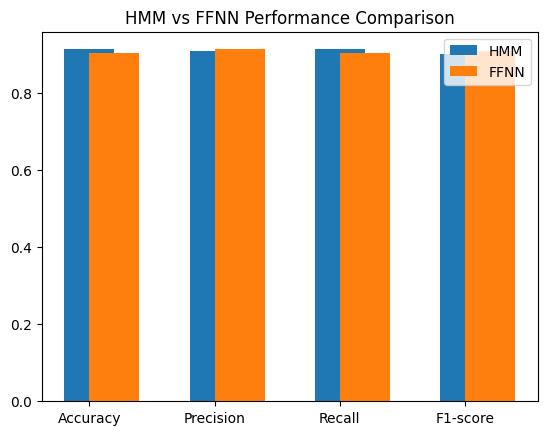

In [59]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1-score"]

hmm_scores = [hmm_acc, hmm_p, hmm_r, hmm_f1]
ffnn_scores = [ffnn_acc, ffnn_p, ffnn_r, ffnn_f1]

x = range(len(metrics))

plt.figure()
plt.bar(x, hmm_scores, width=0.4, label="HMM", align="center")
plt.bar(x, ffnn_scores, width=0.4, label="FFNN", align="edge")

plt.xticks(x, metrics)
plt.legend()
plt.title("HMM vs FFNN Performance Comparison")
plt.show()

Although the HMM model achieves slightly higher accuracy, the Feed-Forward Neural Network achieves a higher F1-score, indicating better performance in detecting named entities. This is because accuracy is dominated by the majority "O" class, while F1-score better reflects performance across all entity classes. The FFNN benefits from word embeddings, allowing it to generalize better and capture semantic relationships.